# 할루시네이션 자가 검증 기능을 활용한 Self-RAG 챗봇 구현

## 실습 목표
---
할루시네이션을 자가 검증하는 기능을 포함하여 간략화된 Self-RAG 기능을 구현하고, 이를 활용하여 챗봇을 구현합니다.

## 실습 목차
---

1. **Self-RAG 모듈 구현**: Self-RAG를 구현하기 위한 모듈을 구현합니다. 
   1. **검색 문서 연관성 평가**: 검색 문서의 연관성을 평가하는 로직을 구현합니다.
   2. **답변 평가**: 답변의 연관성과 지지 정도 (Supportive)를 평가하는 로직을 구현합니다.
   3. **할루시네이션 평가**: 주어진 정보를 바탕으로, AI의 답변의 할루시네이션 여부를 평가하는 로직을 구현합니다.
2. **Self-RAG 챗봇 구현**: 1챕터에서 구현한 모듈과 기타 챗봇 모듈을 결합하여 Self-RAG 챗봇을 구현합니다.

## 0. 환경 설정
필요한 라이브러리를 불러옵니다.

In [1]:
import contextlib
import io
import os
from typing import Optional

import pandas as pd
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

load_dotenv()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_24411/321992817.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

ChatGPT API(`.env`의 `MODEL_NAME`, 예: gpt-4o-mini)를 통해 답변/판단용 모델을 불러오고, Ollama를 통해 `qwen3-embedding:0.6b` 임베딩 모델을 불러옵니다.

* `llm` : 최종 답변을 생성하는 모델
* `route_llm` : 라우팅·연관성·할루시네이션 등 JSON 형식의 판단이 필요한 곳에 쓰는 모델 (`llm`에 JSON 출력 모드를 추가한 것)
* `embeddings` : 문서를 벡터화하는 임베딩 모델

In [2]:
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
# llm.bind(...)로 JSON 강제 출력 옵션을 추가해 route_llm을 만듭니다. (동일 모델, 다른 출력 형식)
route_llm = llm.bind(response_format={"type": "json_object"})
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

Graph State를 정의합니다.
- `question`: 사용자의 원래 질문
- `route`: `init_answer`가 결정한 다음 경로 (`rag` / `excel_data` / `plain_answer`)
- `generation`: LLM이 생성한 최종 답변
- `data`: 검색된 문서 또는 데이터 쿼리 실행 결과
- `code`: 데이터 분석을 위해 LLM이 생성한 파이썬 코드 (엑셀 데이터 경로에서만 사용)

In [3]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    question: str
    route: Optional[str]
    generation: str
    data: str
    code: str

In [4]:
# 정보 평가
def is_data_relevant(state: State) -> dict:
    # LLM이 생성한 텍스트가 문서와 관련이 있는지 확인합니다.
    question = state["question"]
    data = state["data"]
    system_message = """당신은 검색된 문서와 사용자의 질문의 연관성을 평가하는 평가자입니다.
다음은 검색된 문서입니다: \n{data}\n.
문서와 사용자가 입력할 질문이 연관이 있다면 true, 그렇지 않다면 false를 선택하세요.
답변은 'relevant' key(boolean) 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", "{question}"))

    relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # route_llm은 JSON으로만 답하므로 JsonOutputParser로 바로 파싱합니다.
    router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "data": data})
    return result

모듈이 잘 작동하는지 확인해봅시다.

In [5]:
# 파이썬 코드 문서 (이론 과정에서 사용한 예시입니다)
relevant_document = "math.gcd(*integers): 지정된 정수 인자의 최대 공약수를 반환합니다. 인자 중 하나가 0이 아니면, 반환된 값은 모든 인자를 나누는 가장 큰 양의 정수입니다. 모든 인자가 0이면, 반환 값은 0입니다. 인자가 없는 gcd()는 0을 반환합니다."
irrelevant_document = "re.search(pattern, string, flags=0): string을 통해 스캔하여 정규식 pattern이 일치하는 첫 번째 위치를 찾고, 대응하는 일치 객체를 반환합니다."

question = "파이썬에서 공약수를 계산하는 방법을 알려주세요."

relevant_state = State(
    question=question, generation="", data=relevant_document, code=""
)
irrelevant_state = State(
    question=question, generation="", data=irrelevant_document, code=""
)

# 문서와 질문의 연관성을 평가합니다.
is_data_relevant(relevant_state), is_data_relevant(irrelevant_state)

({'relevant': True}, {'relevant': False})

이 판단이 항상 안정적인 것은 아닙니다. 판단 기준이 모호하면(`irrelevant_document`가 명백히 무관한데도) 모델이 관련 있다고 잘못 판단할 수 있습니다.

**개선 방법**
- **프롬프트에 판단 기준 구체화**: "주제가 다르면 표면적 유사성과 무관하게 false를 선택하라"는 문장을 시스템 메시지에 추가.
- **Few-shot 예시 추가**: relevant/irrelevant 예시 한두 쌍을 프롬프트에 넣어 판단 기준을 명확히 보여주기.

### 1.2. 답변 평가
---
답변의 유용성과 지지 정도 (Supportive)를 평가하는 모듈을 구현합니다.

In [6]:
# 답변 지지 평가
def is_answer_supportive(state: State) -> dict:
    # 생성된 텍스트가 질문과 관련이 있는지 확인합니다.
    question = state["question"]
    generation = state["generation"]
    system_message = (
        """당신은 AI의 답변이 사용자의 질문에 대한 해답인지 평가하는 평가자입니다."""
    )
    # 정보와 AI의 답변을 모두 사용자 프롬프트에 추가합니다. 함수 이름과 달리 'supportive'가 아닌
    # 'answer' key에 결과를 저장하라는 지시는 다른 평가 함수들과 지시사항 형식을 통일하기 위함입니다.
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자의 질문에 대한 해답이면 true, 아니라면 false를 선택하세요.
'answer' key(boolean) 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    relevant_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # route_llm은 JSON으로만 답하므로 JsonOutputParser로 바로 파싱합니다.
    router_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "generation": generation})
    return result

In [7]:
# 유용성 평가
def is_answer_useful(state: State) -> dict:
    # 생성된 텍스트가 질문에 대한 해답인지 확인합니다.
    question = state["question"]
    generation = state["generation"]
    system_message = """당신은 AI의 답변이 사용자에게 유용한지 평가하는 평가자입니다."""
    user_message = """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자에게 유용하다면 true, 아니라면 false를 선택하세요.
'useful' key(boolean) 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    useful_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # route_llm은 JSON으로만 답하므로 JsonOutputParser로 바로 파싱합니다.
    router_chain = useful_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"question": question, "generation": generation})
    return result

먼저 위의 모듈을 사용하지 않았을 때의 결과를 확인해 보겠습니다.

간단한 질의응답 체인을 만들고, 질문과 관련 있는 문서와 관런 없는 문서를 각각 증강한 질문에 대한 답변을 저장합니다.

In [8]:
template = [
    ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
    ("human", "정보: {data}.\n{question}."),
]
temp_prompt = ChatPromptTemplate.from_messages(template)
temp_chain = temp_prompt | llm | StrOutputParser()

relevant_answer = temp_chain.invoke(
    {"data": relevant_document, "question": question}
)
irrelevant_answer = temp_chain.invoke(
    {"data": irrelevant_document, "question": question}
)

print("relevant Answer:", relevant_answer)
print("Irrelevant Answer:", irrelevant_answer)

relevant Answer: 파이썬에서 최대 공약수(GCD)를 계산하는 방법은 `math` 모듈의 `gcd` 함수를 사용하는 것입니다. 이 함수는 두 개의 정수를 인자로 받아 그들의 최대 공약수를 반환합니다. 여러 개의 정수에 대한 최대 공약수를 계산하려면 `functools.reduce`와 함께 사용할 수 있습니다.

다음은 `math.gcd`를 사용하는 예제입니다:

```python
import math
from functools import reduce

# 두 개의 정수에 대한 최대 공약수
a = 48
b = 18
gcd_ab = math.gcd(a, b)
print(f"{a}와 {b}의 최대 공약수는 {gcd_ab}입니다.")

# 여러 개의 정수에 대한 최대 공약수
numbers = [48, 18, 30]
gcd_all = reduce(math.gcd, numbers)
print(f"{numbers}의 최대 공약수는 {gcd_all}입니다.")
```

위 코드에서:
- `math.gcd(a, b)`는 두 정수 `a`와 `b`의 최대 공약수를 계산합니다.
- `reduce(math.gcd, numbers)`는 리스트 `numbers`에 있는 모든 정수의 최대 공약수를 계산합니다.

이렇게 하면 파이썬에서 최대 공약수를 쉽게 계산할 수 있습니다.
Irrelevant Answer: 파이썬에서 두 수의 공약수를 계산하는 방법은 여러 가지가 있지만, 가장 일반적인 방법은 유클리드 호제법을 사용하는 것입니다. 아래는 두 수의 공약수를 계산하는 간단한 예제입니다.

```python
def gcd(a, b):
    while b:
        a, b = b, a % b
    return a

# 사용 예시
num1 = 48
num2 = 18
result = gcd(num1, num2)
print(f"{num1}와 {num2}의 공약수는 {result}입니다.")
```

이 코드는 두 수 `num1`과 `num2`의 최대공약수(Greatest Com

증강한 문서와 무관하게, LLM 모델이 자체적으로 학습한 텍스트를 바탕으로 둘 다 올바른 답변을 반환한 것을 확인할 수 있습니다. 

두 텍스트에 더해, 임의로 작성한 정말 연관이 없는 답변까지 활용하여 테스트 해보겠습니다.

In [9]:
# 모델이 답변한 결과
revelent_state = State(
    question=question, generation=relevant_answer, data=relevant_document, code=""
) # 모델이 올바른 문서를 보고 올바르게 대답함.
irrelevant_state = State(
    question=question, generation=irrelevant_answer, data=irrelevant_document, code=""
) # 모델이 올바르지 않은 문서를 봤지만 자신의 지식으로 올바르게 대답함.
true_irrelevant_state = State(
    question=question,
    generation="re.search를 통해 string을 통해 스캔하여 정규식 pattern이 일치하는 첫 번째 위치를 찾고, 대응하는 일치 객체를 반환할 수 있습니다.",
    data="",
    code="",
) # 모델이 아예 올바르지 않은 대답을 했다고 가정.

# 답변과 질문의 연관성을 평가합니다.
is_answer_supportive(revelent_state), is_answer_supportive(
    irrelevant_state
), is_answer_supportive(true_irrelevant_state)

({'answer': True}, {'answer': True}, {'answer': False})

In [10]:
is_answer_useful(revelent_state), is_answer_useful(
    irrelevant_state
), is_answer_useful(true_irrelevant_state)

({'useful': True}, {'useful': True}, {'useful': False})

답변을 올바로 한 앞의 두 경우에는 `True`, 마지막 경우에는 `False`를 출력한 것을 볼 수 있습니다.

### 1.3. 검색 문서 기반 할루시네이션 평가
---
검색된 문서를 바탕으로 생성한 답변의 할루시네이션 정도를 평가하는 모듈을 구현합니다.

In [11]:
# 할루시네이션 평가
def is_hallucinated(state: State) -> dict:
    # 생성된 텍스트가 질문에 대한 해답인지 확인합니다.
    generation = state["generation"]
    docs = state["data"]
    system_message = """당신은 주어진 근거 문서를 바탕으로 AI의 답변이 진실인지 여부를 평가하는 평가자입니다."""
    user_message = """근거 문서: {docs}
AI의 답변: {generation}

AI의 답변에 등장하는 구체적인 내용(함수 이름, 개념, 숫자 등)이 근거 문서 안에 실제로 존재하는지 하나씩 확인하세요.
답변의 내용이 일반적으로 사실이더라도, 근거 문서에서 확인할 수 없다면 False입니다.
답변은 'answer'(true/false) key가 있는 JSON으로 답변하세요."""

    message_list = [("system", system_message)]
    message_list.append(("human", user_message))

    hallucination_judge_prompt = ChatPromptTemplate.from_messages(message_list)
    # route_llm은 JSON으로만 답하므로 JsonOutputParser로 바로 파싱합니다.
    router_chain = hallucination_judge_prompt | route_llm | JsonOutputParser()

    result = router_chain.invoke({"generation": generation, "docs": docs})
    return result

앞서 살펴본 `relevant_state` 와 `irrelevant_state` 모두 주어진 문서와 무관하게 사용자의 질문에 잘 답한 것을 확인할 수 있었습니다.

하지만, `irrelevant_state`는 주어진 근거 문서 (re.search 함수의 정의) 와 관련이 없는 답변을 생성한 것과 같으므로, 일종의 할루시네이션 으로 해석할 수도 있습니다.

실제로 그런 결과가 나오는지 확인해봅시다.

In [12]:
is_hallucinated(revelent_state), is_hallucinated(irrelevant_state)

({'answer': True}, {'answer': False})

## 2. Self-RAG 챗봇 구현
---
방금 구현한 모듈과 기타 챗봇 모듈을 결합하여 Self-RAG 챗봇을 구현합니다.

**이 챗봇이 다루는 데이터**
- `RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf`: "AI 산업 현황"과 관련된 질문에 사용되는 RAG 문서
- `한국지능정보사회진흥원_인공지능 학습용 데이터 구축 현황_20210104.csv`: pandas DataFrame으로 불러와, 엑셀 데이터 분석 경로에서 LLM이 직접 분석 코드를 생성·실행할 때 사용됩니다.

**이 챗봇이 받는 질문 종류**
질문 내용에 따라 아래 세 경로 중 하나로 자동 라우팅됩니다.
- **"인공지능 산업 동향"** 관련 질문 → PDF를 검색하는 RAG 경로
- **"인공지능 데이터 프로필"** 관련 질문 → CSV를 분석하는 엑셀 데이터 경로
- **그 외** → RAG/데이터 없이 LLM이 아는 지식으로 바로 답변

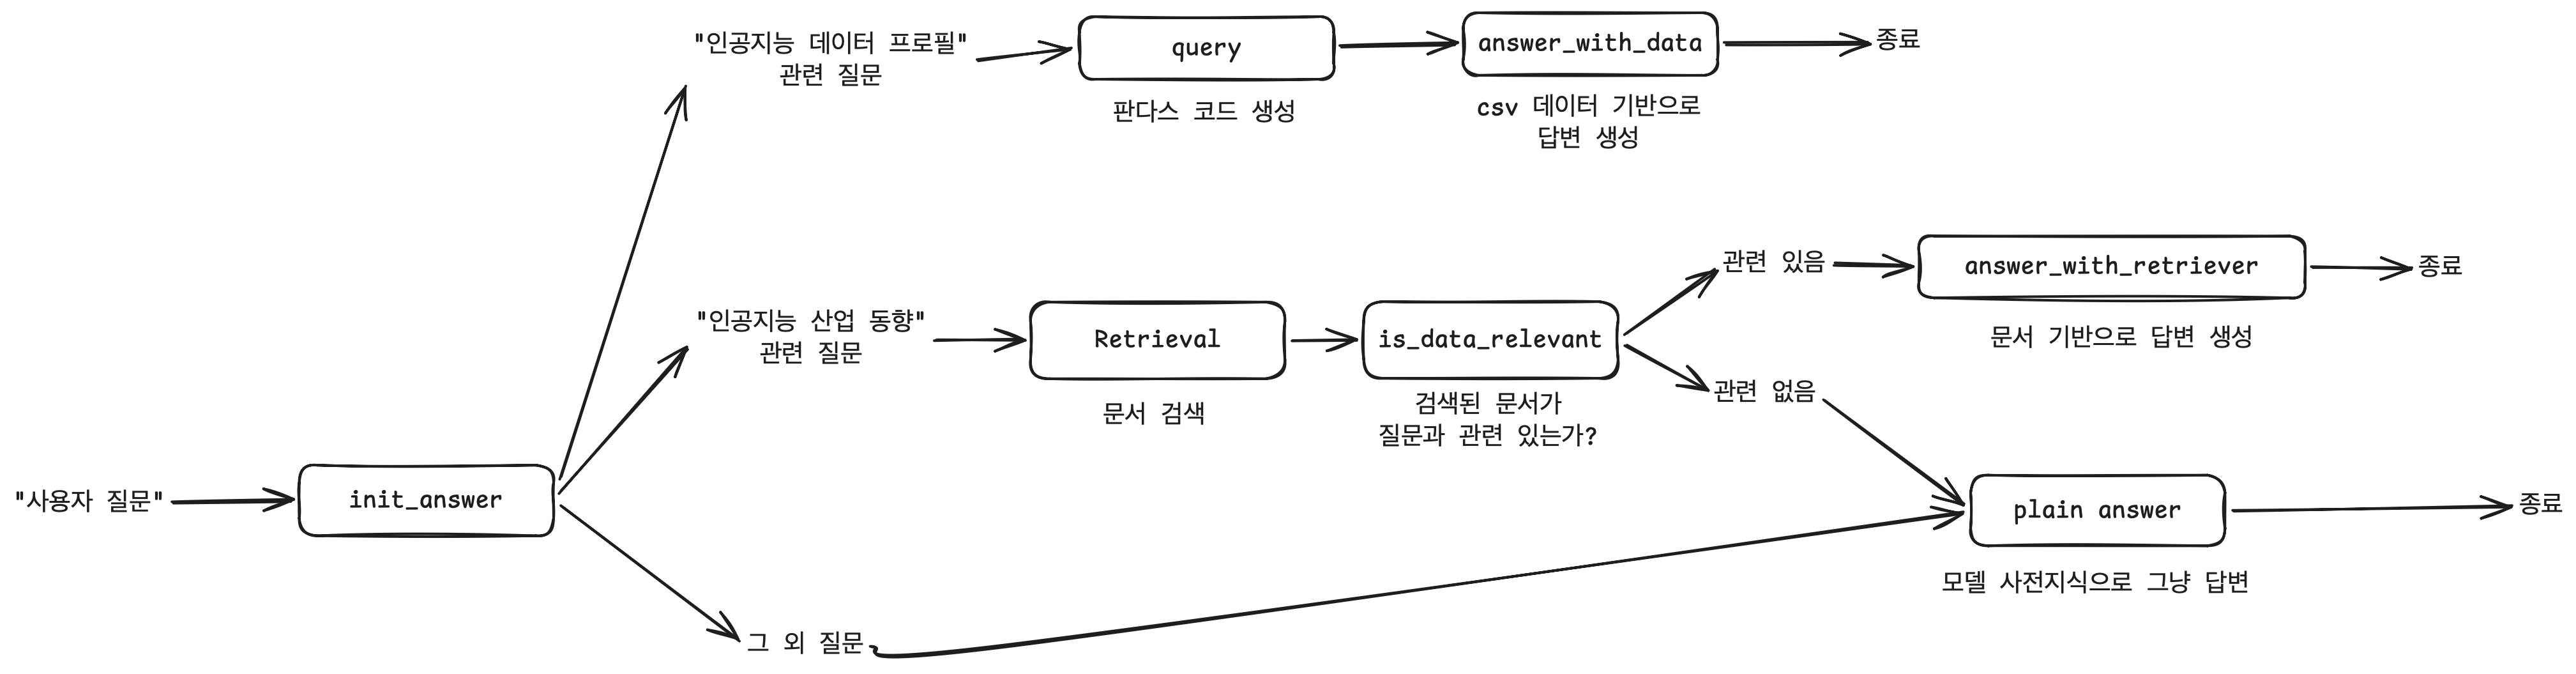

데이터를 불러오고, 유틸리티 함수를 정의합니다.

In [13]:
excel_data_name = "한국지능정보사회진흥원_인공지능 학습용 데이터 구축 현황_20210104.csv"
pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"
persist_dir = "./vectorstore/chroma_ai_industry"

data_dir = "./data"
df_ai_train_data_dist = pd.read_csv(
    os.path.join(data_dir, excel_data_name), index_col=None
)

# 이미 임베딩된 벡터스토어가 있으면 그대로 불러오고, 없으면 PDF를 새로 임베딩해서 저장합니다.
if os.path.exists(persist_dir):
    vectorstore = Chroma(embedding_function=embeddings, persist_directory=persist_dir)
    print(f"[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: {vectorstore._collection.count()})")
else:
    pdf_loader = PyPDFLoader(os.path.join(data_dir, pdf_data_name))
    pdf_docs = pdf_loader.load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
    splited_pdf_docs = text_splitter.split_documents(pdf_docs)
    vectorstore = Chroma.from_documents(
        documents=splited_pdf_docs, embedding=embeddings, persist_directory=persist_dir,
    )
    print(f"[vectorstore] 새로 임베딩 완료 (저장된 벡터 수: {vectorstore._collection.count()})")

db_retriever = vectorstore.as_retriever()

[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: 18)


In [14]:
# LLM이 생성한 코드를 파싱하는 함수를 정의합니다.
def python_code_parser(input: str) -> str:
    # LLM은 대부분 ``` 블럭 안에 코드를 출력합니다. 이를 활용합니다.
    # ```python (코드) ```, 혹은 ``` (코드) ``` 형태로 출력됩니다. 두 경우 모두에 대응하도록 코드를 작성합니다.
    processed_input = input.replace("```python", "```").strip()
    parsed_input_list = processed_input.split("```")

    # 만약 ``` 블럭이 없다면, 입력 텍스트 전체가 코드라고 간주합니다.
    # 아닐 경우 이어지는 코드 실행 과정에서 예외 처리를 통해 오류를 확인할 수 있습니다.
    if len(parsed_input_list) == 1:
        return processed_input

    # 코드 부분만 추출합니다.
    # LLM은 여러 코드 블럭에 걸쳐 필요한 코드를 출력할 수 있으므로, 코드가 있는 홀수 번째 텍스트를 모두 저장합니다.
    parsed_code_list = []
    for i in range(1, len(parsed_input_list), 2):
        parsed_code_list.append(parsed_input_list[i])

    # 코드 부분을 하나로 합칩니다.
    return "\n".join(parsed_code_list)


# 생성한 코드를 실행하는 함수를 정의합니다.
def run_code(input_code: str):
    output = io.StringIO()
    try:
        with contextlib.redirect_stdout(output):
            # 코드가 실행하면서 출력한 모든 결과를 캡쳐합니다.
            exec(input_code, {"df_ai_train_data_dist": df_ai_train_data_dist})
    except Exception as e:
        # 에러가 발생할 경우, 이를 StringIO 객체에 저장합니다.
        print(f"Error: {e}", file=output)
    # StringIO 객체에 저장된 값을 반환합니다.
    return output.getvalue()

In [15]:
# python_code_parser, run_code가 어떤 역할을 하는지 간단히 확인해봅시다.

# LLM이 실제로 응답할 법한 형태(설명 + ```python 코드 블록```)를 흉내낸 예시 문자열입니다.
fake_llm_output = """다음은 df_ai_train_data_dist의 행 개수를 세는 코드입니다.

```python
print(len(df_ai_train_data_dist))
print(df_ai_train_data_dist.columns.tolist())
```
"""

# 1. python_code_parser: 설명 텍스트를 제거하고 ```코드``` 블록 안의 코드만 추출합니다.
parsed_code = python_code_parser(fake_llm_output)
print("=== 추출된 코드 ===")
print(parsed_code)

# 2. run_code: 추출된 코드를 실제로 실행하고, 그 출력(print 결과)을 문자열로 반환합니다.
result = run_code(parsed_code)
print("=== 실행 결과 ===")
print(result)

=== 추출된 코드 ===

print(len(df_ai_train_data_dist))
print(df_ai_train_data_dist.columns.tolist())

=== 실행 결과 ===
116
['연도', '분야', '주요내용']



단순 답변, 엑셀 데이터 분석, RAG 기능을 구현합니다.
- 대화 기억 기능, 데이터 그래프 작성 기능은 이번 실습에서 사용하지 않습니다.

In [16]:
df_name = "df_ai_train_data_dist"
df_columns = ", ".join(df_ai_train_data_dist.columns)

# [엑셀 데이터 경로] 질문에 답하기 위한 pandas 코드를 LLM으로 생성하고 실행해, 그 결과를 state에 담습니다.
def query(state: State) -> State:
    print("[excel_data] pandas 코드 생성 및 실행 중...")
    question = state["question"]

    # df_name, df_columns는 질문마다 바뀌지 않는 값이라 f-string으로 미리 채워 넣습니다.
    system_message = f"""당신은 주어진 데이터를 분석하는 데이터 분석가입니다.
주어진 DataFrame에서 데이터를 출력하여 주어진 질문에 답할 수 있는 파이썬 코드를 작성하세요.
{df_name} DataFrame에 액세스할 수 있습니다.
`{df_name}` DataFrame에는 다음과 같은 열이 있습니다: {df_columns}
데이터는 이미 로드되어 있으므로 데이터 로드 코드를 생략해야 합니다."""

    prompt_with_data_info = ChatPromptTemplate.from_messages(
        [("system", system_message), ("human", "{question}")]
    )
    code_generate_chain = prompt_with_data_info | llm | StrOutputParser() | python_code_parser
    code = code_generate_chain.invoke({"question": question})
    data = run_code(code)
    print(f"[excel_data] 실행 결과 미리보기: {data[:100]}")
    return {"question": question, "code": code, "data": data, "generation": code}


# [엑셀 데이터 경로] query 노드가 실행해서 얻은 데이터(data)를 바탕으로 질문에 대한 최종 답변을 생성합니다.
def answer_with_data(state: State) -> State:
    print("[answer_with_data] 쿼리 결과를 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]

    reasoning_with_data_chain = (
        ChatPromptTemplate.from_messages([
            ("system", "당신은 데이터를 바탕으로 질문에 답하는 데이터 분석가입니다. 사용자가 입력한 데이터를 바탕으로 질문에 대답하세요."),
            ("human", "데이터: {data}\n{question}"),
        ])
        | llm
        | StrOutputParser()
    )
    generation = reasoning_with_data_chain.invoke({"data": data, "question": question})
    return {
        "question": question,
        "code": state["code"],
        "data": data,
        "generation": generation,
    }


# [일반 답변 경로] RAG나 데이터 없이, LLM이 아는 지식만으로 질문에 바로 답변합니다.
def answer(state: State) -> State:
    print("[plain_answer] RAG/데이터 없이 답변 생성 중...")
    question = state["question"]
    return {"question": question, "generation": llm.invoke(question).content}


# [RAG 경로] db_retriever로 질문과 유사한 PDF 문서를 검색해 state의 data에 담습니다.
def retrieval(state: State) -> State:
    def get_retrieved_text(docs):
        return "\n".join(doc.page_content for doc in docs)

    print("[rag] 문서 검색 중...")
    question = state["question"]
    retrieval_chain = db_retriever | get_retrieved_text
    data = retrieval_chain.invoke(question)
    print(f"[rag] 검색된 내용 미리보기: {data[:100]}")
    return {"question": question, "data": data}


# [RAG 경로] retrieval 노드가 검색한 문서(data)를 바탕으로 질문에 대한 답변을 생성합니다.
def answer_with_retrieved_data(state: State) -> State:
    print("[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]

    qa_chain = (
        ChatPromptTemplate.from_messages([
            ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
            ("human", "정보: {data}.\n{question}."),
        ])
        | llm
        | StrOutputParser()
    )
    generation = qa_chain.invoke({"data": data, "question": question})
    return {"question": question, "data": data, "generation": generation}

In [17]:
def init_answer(state: State) -> State:
    print("[init_answer] 질문 라우팅 중...")
    route_system_message = """당신은 사용자의 질문에 RAG, 엑셀 데이터 중 어떤 것을 활용할 수 있는지 결정하는 전문가입니다.
인공지능 산업 동향과 관련된 질문이라면 RAG를 활용하세요.
인공지능 데이터 프로필과 관련된 질문이라면 excel_data를 활용하세요.
둘 다 아니라면, plain_answer로 충분합니다.
주어진 질문에 맞춰 `rag`, `excel_data`, `plain_answer`중 하나를 선택하세요.
답변은 `route` key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
    route_prompt = ChatPromptTemplate.from_messages(
        [("system", route_system_message), ("human", "{question}")]
    )
    router_chain = route_prompt | route_llm | JsonOutputParser()

    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    print(f"[init_answer] 선택된 경로: {route}")
    return {"question": question, "route": route}

앞서 구성한 모듈을 모두 활용하여 그래프를 구성합니다.

Self-RAG 논문에서는 서로 다른 K개의 문서를 한번에 검색하고, 한번에 평가한 후 가장 적합한 답변을 선별합니다.

저희는 이를 간략화하여 한번에 하나씩만 검색 및 생성하고, 적합 여부를 평가하는 로직으로 구현하겠습니다.


In [18]:
workflow = StateGraph(State)
workflow.add_node("init_answer", init_answer)
workflow.add_node("excel_data", query)
workflow.add_node("rag", retrieval)
workflow.add_node("answer_with_data", answer_with_data)
workflow.add_node("plain_answer", answer)
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)

workflow.add_edge(START, "init_answer")
workflow.add_edge("plain_answer", END)
workflow.add_edge("answer_with_data", END)
workflow.add_edge("excel_data", "answer_with_data")

# 1. init_answer가 결정한 route로 분기합니다.
workflow.add_conditional_edges(
    "init_answer",
    lambda state: state["route"],
    {"excel_data": "excel_data", "rag": "rag", "plain_answer": "plain_answer"},
)

# 2. 검색한 문서가 질문과 관련 있는지 평가합니다. 관련 없으면 plain_answer로 이동합니다.
workflow.add_conditional_edges(
    "rag",
    lambda state: "yes" if is_data_relevant(state)["relevant"] else "no",
    {"yes": "answer_with_retrieval", "no": "plain_answer"},
)

def judge_answer(state: State) -> str:
    print("[judge_answer] 답변 평가 중...")
    try:
        hallucinated = is_hallucinated(state)["answer"]
        print(f"[judge_answer] 진실 여부: {'진실입니다' if hallucinated else '진실이 아닙니다'}")
    except KeyError:
        hallucinated = True
        print("[judge_answer] 진실 여부를 알 수 없어 통과 처리합니다.")

    if not hallucinated:
        return "hallucinated"

    try:
        supportive = is_answer_supportive(state)["answer"]
        print(f"[judge_answer] 지지 여부: {'지지함' if supportive else '지지하지 않음'}")
    except KeyError:
        supportive = True
        print("[judge_answer] 지지 여부를 알 수 없어 통과 처리합니다.")

    try:
        useful = is_answer_useful(state)["useful"]
        print(f"[judge_answer] 유용성: {'유용함' if useful else '유용하지 않음'}")
    except KeyError:
        useful = True
        print("[judge_answer] 유용성을 알 수 없어 통과 처리합니다.")

    if (supportive or useful) and hallucinated:
        return "yes"
    return "no"

workflow.add_conditional_edges(
    "answer_with_retrieval",
    judge_answer,
    {"yes": END, "no": "plain_answer", "hallucinated": "answer_with_retrieval"},
)

graph = workflow.compile()

모델 구성을 끝마쳤으면, 한번 사용해 봅시다.

Note. LLM 특성상 의도하지 않은 방식으로 작동하지 않을 가능성이 있습니다.

예시 질문과 예상 답변)

1. RAG 경로 (PDF: AI 산업 동향)

    * 질문: "2023년 AI 인덱스 보고서는 누가 발표했어?"
    * 예상 답변: 미국 스탠포드 대학의 HAI(Human-Centered AI Institute)가 2023년 4월에 발표했다는 내용

2. 엑셀 데이터 경로 (CSV: AI 학습용 데이터 구축 현황)

    * 질문: "2017년에 구축된 AI 학습용 데이터에는 어떤 분야가 있었어?"
    * 예상 답변: 법률, 특허, 일반상식, 이미지 등 (CSV에서 연도==2017로 필터링하면 나오는 분야들)

3. 일반 답변 경로 (RAG/데이터 불필요)

    * 질문: "인공지능이 뭐야?"
    * 예상 답변: 문서나 데이터 없이도 LLM이 일반 지식으로 무난히 답할 수 있는 개념 질문.

In [19]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        # graph.invoke 함수를 사용하여 그래프를 실행하고, 최종 결과를 반환합니다.
        # 답변 생성에는 약 1분 정도 소요됩니다.
        try:
            print(
                "Assistant: ",
                graph.invoke({"question": question})["generation"],
            )
        except Exception as e:
            print("Assistant: 오류가 발생했습니다. 다시 시도해주세요.")
            print(e)

[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: rag
[rag] 문서 검색 중...
[rag] 검색된 내용 미리보기: - 4 -
제2장인공지능산업현황및전망제1절AI 산업 현황 1.전 세계 AI 현황 및 수준2023년 4월, 미국 스탠포드 대학의 HAI는 2023년 AI 분야의 국제적인 수준을 비교
[answer_with_retrieval] 검색된 문서를 바탕으로 답변 생성 중...
[judge_answer] 답변 평가 중...
[judge_answer] 진실 여부: 진실입니다
[judge_answer] 지지 여부: 지지함
[judge_answer] 유용성: 유용함
Assistant:  2023년 AI 인덱스 보고서는 미국 스탠포드 대학의 HAI(인공지능 연구소)에서 발표하였습니다.
[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: excel_data
[excel_data] pandas 코드 생성 및 실행 중...
[excel_data] 실행 결과 미리보기: <StringArray>
['법률', '특허', '일반상식', '이미지']
Length: 4, dtype: str

[answer_with_data] 쿼리 결과를 바탕으로 답변 생성 중...
Assistant:  2017년에 구축된 AI 학습용 데이터에는 '법률', '특허', '일반상식', '이미지'와 같은 다양한 분야가 포함되어 있었습니다. 이러한 분야들은 AI 모델이 다양한 주제에 대해 학습하고 이해할 수 있도록 돕기 위해 선택되었습니다.
[init_answer] 질문 라우팅 중...
[init_answer] 선택된 경로: plain_answer
[plain_answer] RAG/데이터 없이 답변 생성 중...
Assistant:  인공지능(AI, Artificial Intelligence)은 컴퓨터 시스템이나 기계가 인간의 지능을 모방하여 학습, 추론, 문제 해결, 이해, 언어 처리 등의 작업을 수행할 수 있도록 하는 기술입니다